In [1]:
# ============================================
# Ethical AI Project - Starter Notebook
# Dataset: German Credit
# Task: Predict creditworthiness
# ============================================

# -----------------------------
# 1. Install required libraries
# -----------------------------
!pip install pandas numpy scikit-learn matplotlib seaborn requests --quiet

import pandas as pd
import numpy as np
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Libraries installed and imported.")

# -----------------------------
# 2. Download dataset
# -----------------------------
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

data_path = data_dir / "german_credit_data.csv"
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

if not data_path.exists():
    print("Downloading German Credit dataset...")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

# -----------------------------
# 3. Load dataset
# -----------------------------
df = pd.read_csv(data_path)

print("\nDataset loaded successfully")
print("Shape:", df.shape)

print("\nFirst rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isna().sum())

# -----------------------------
# 4. Standardize column names
# -----------------------------
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nStandardized columns:")
print(df.columns)

# -----------------------------
# 5. Identify target variable robustly
# -----------------------------
possible_targets = ["credit_risk", "class", "risk", "target"]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(f"Could not find target column. Tried: {possible_targets}")

print("\nDetected target column:", target_col)
print("Raw target unique values:", df[target_col].unique())

# Handle common target formats robustly
if df[target_col].dtype == "object":
    cleaned = df[target_col].astype(str).str.strip().str.lower()

    # Case 1: already encoded as strings "0"/"1"
    if set(cleaned.unique()).issubset({"0", "1"}):
        df[target_col] = cleaned.astype(int)

    # Case 2: text labels
    elif set(cleaned.unique()).issubset({"good", "bad"}):
        df[target_col] = cleaned.map({"good": 1, "bad": 0})

    else:
        raise ValueError(
            f"Unsupported target values in {target_col}: {sorted(cleaned.unique())}"
        )
else:
    # numeric target
    df[target_col] = df[target_col].astype(int)

if df[target_col].isna().any():
    raise ValueError("Target column contains NaN after conversion.")

print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

# -----------------------------
# 6. Create cleaner protected attributes
# -----------------------------
# Extract binary sex from personal_status_sex
if "personal_status_sex" in df.columns:
    df["sex"] = df["personal_status_sex"].apply(
        lambda x: "female" if "female" in str(x).lower() else "male"
    )

# Common fairness grouping for age
if "age" in df.columns:
    df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

print("\nProtected attributes available:")
for col in ["sex", "age", "age_group"]:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts())

# -----------------------------
# 7. Split dataset
# -----------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

# -----------------------------
# 8. Basic preprocessing pipeline
# -----------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed training matrix shape:", X_train_processed.shape)
print("Processed test matrix shape:", X_test_processed.shape)

# Optional: keep protected attributes aside for later fairness analysis
protected_cols = [c for c in ["sex", "age", "age_group"] if c in X_train.columns]
A_train = X_train[protected_cols].copy() if protected_cols else pd.DataFrame(index=X_train.index)
A_test = X_test[protected_cols].copy() if protected_cols else pd.DataFrame(index=X_test.index)

print("\nProtected attribute preview:")
print(A_train.head())

print("\nGerman Credit dataset ready for modeling.")

Libraries installed and imported.
Download complete.

Dataset loaded successfully
Shape: (1000, 21)

First rows:
                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rate      

In [ ]:
# ==========================================================
# HIGH-LEVEL GUIDE FOR PROJECT MODULE 1
# Do not implement everything at once.
# Work step by step after the provided starter code.
# ==========================================================

# 1. Inspect the processed dataset
#    - Check class balance in the target variable.
#    - Check the distribution of the protected attribute(s).
#    - Make sure you understand what positive and negative predictions mean.

# 2. Train a baseline model
#    - Choose a reasonable classifier (for example logistic regression,
#      decision tree, random forest, gradient boosting, etc.).
#    - Briefly justify why that model is appropriate for this task.

# 3. Evaluate predictive performance
#    - Compute accuracy, precision, recall, and F1-score on the test set.
#    - Explain what each metric tells you in the context of this dataset.

# 4. Compute fairness metrics by demographic group
#    - Compare groups separately for each protected attribute you selected.
#    - Include metrics such as:
#         * Demographic parity / selection rate differences
#         * Equalized odds components (for example TPR/FPR differences)
#         * Calibration-related comparisons if your approach supports them
#    - Clearly identify which groups have better or worse outcomes.

# 5. Visualize disparities
#    - Create plots showing:
#         * Prediction/selection rates by group
#         * Error rates by group
#         * Fairness metric gaps across groups
#    - Make plots easy to read and label them clearly.

# 6. Apply one preprocessing bias mitigation method
#    - Choose ONE:
#         * Reweighting training samples
#         * Resampling demographic groups
#    - Retrain the same baseline model after mitigation.
#    - Recompute both performance and fairness metrics.
#    - Compare the new results against the baseline.

# 7. Apply one in-processing mitigation method
#    - Choose a training-time fairness intervention such as:
#         * Fairness constraints
#         * Fairness-aware optimization
#         * Adversarial debiasing
#         * A fairness-aware ML library
#    - Retrain and evaluate again.
#    - Compare baseline vs preprocessing vs in-processing.

# 8. Analyze trade-offs
#    - Compare fairness improvements against any drop in predictive accuracy.
#    - Determine which approach gives the best balance for this dataset.
#    - Identify which fairness metric was hardest to improve.

# 9. Write deployment recommendations
#    - State whether you would recommend real-world deployment.
#    - Discuss which fairness criteria matter most in this setting.
#    - Explain possible harms if biased predictions are used in practice.
#    - Note important limitations in your analysis.

# 10. Final deliverables
#    - Completed notebook with code, outputs, and visualizations
#    - Technical report interpreting model performance, fairness results,
#      mitigation effects, trade-offs, and recommendations


=== Justification for baseline model chosen ===
Logistic regression is interpretable, making it suitable for fairness analysis since decision boundaries and feature effects are easier to understand.
It outputs probabilities, which are necessary for evaluating calibration metrics (ECE, Brier score).
It is a standard benchmark model in credit scoring tasks, providing a reliable baseline before using more complex models.
It allows us to assess whether fairness issues arise from the data itself, rather than model complexity.

=== Baseline predictive performance (overall) ===
Accuracy : 0.7050
Precision: 0.7755
Recall   : 0.8143
F1-score : 0.7944

=== Interpretation of metrics ===
Accuracy = 0.7050 → About 70.5% of all test people are predicted correctly (either correctly approved or correctly rejected). Accuracy alone can hide fairness issues because it averages across groups.
Precision = 0.7755 → Among predictions of creditworthy (ŷ = 1), 77.6% are truly creditworthy. Approvals are fairl

,group,n,selection_rate,tpr,fpr,ece,brier
0,female,60,0.6667,0.725,0.55,0.1809,0.2293
1,male,140,0.7643,0.850,0.55,0.0638,0.1644




=== Fairness metrics by age_group ===


,group,n,selection_rate,tpr,fpr,ece,brier
0,age_25_and_over,172,0.7442,0.8387,0.50,0.0536,0.1688
1,under_25,28,0.6786,0.6250,0.75,0.3510,0.2768




=== Fairness Audit by sex ===
Demographic Parity (Selection Rate Gap): 0.0976 met
  - male approval rate: 0.7643
  - female approval rate: 0.6667
Equalized Odds (TPR Gap: 0.1250, FPR Gap: 0.0000) NOT met
Calibration (ECE Gap: 0.1172) NOT met
Overall: female group shows worse outcomes, experiences the largest disparities, and has the strongest fairness problems.


=== Fairness Audit by age_group ===
Demographic Parity (Selection Rate Gap): 0.0656 met
  - age_25_and_over approval rate: 0.7442
  - under_25 approval rate: 0.6786
Equalized Odds (TPR Gap: 0.2137, FPR Gap: 0.2500) NOT met
Calibration (ECE Gap: 0.2975) NOT met
Overall: under_25 group shows worse outcomes, experiences the largest disparities, and has the strongest fairness problems.


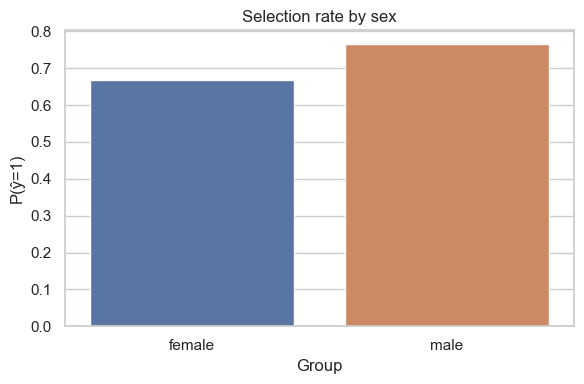

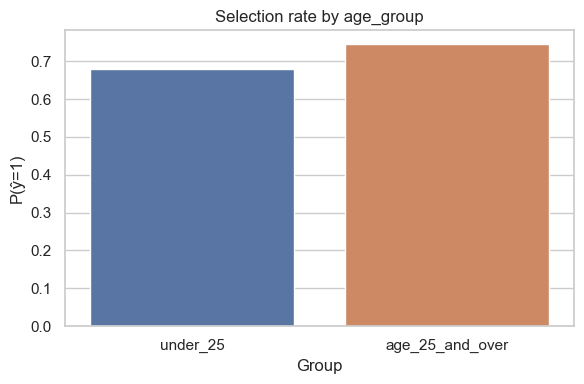

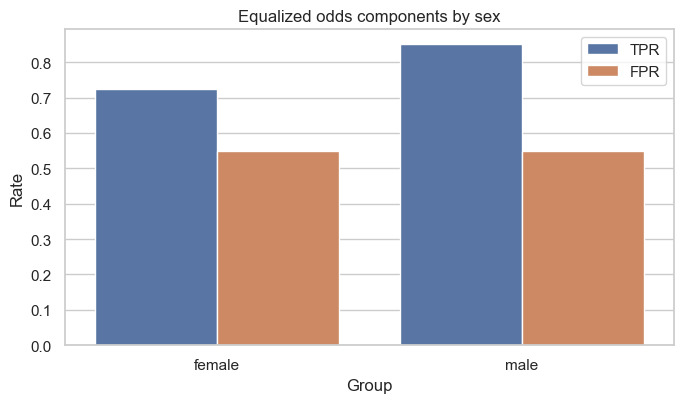

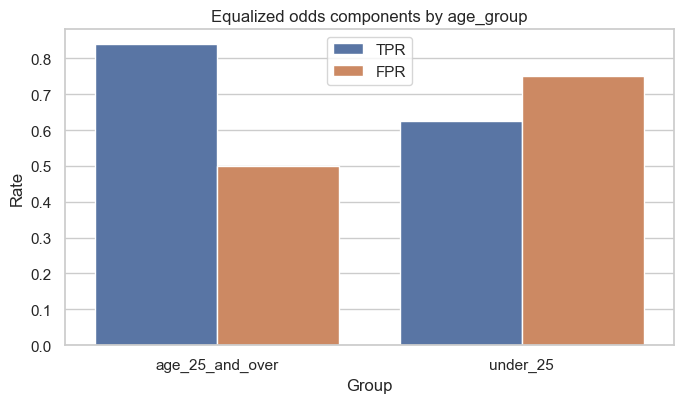

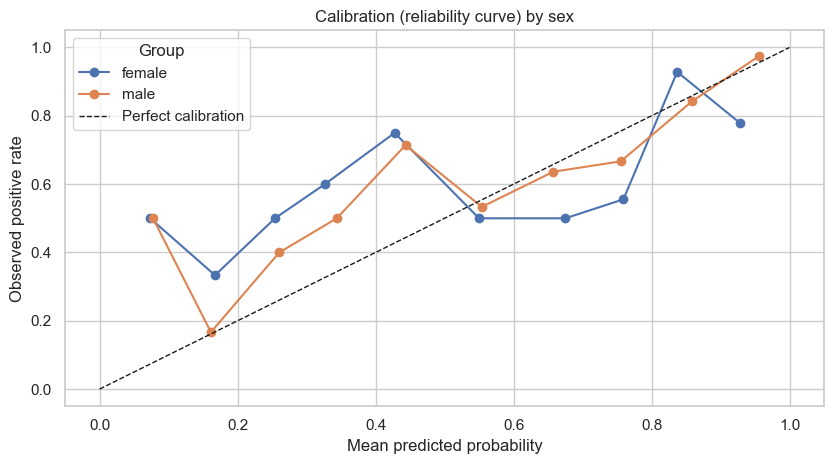

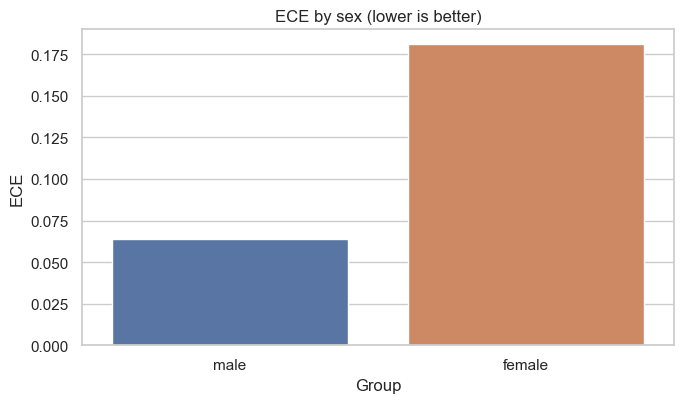

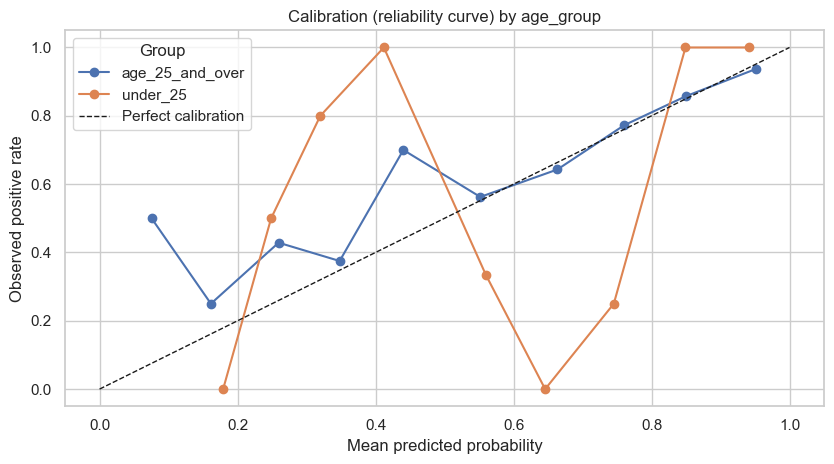

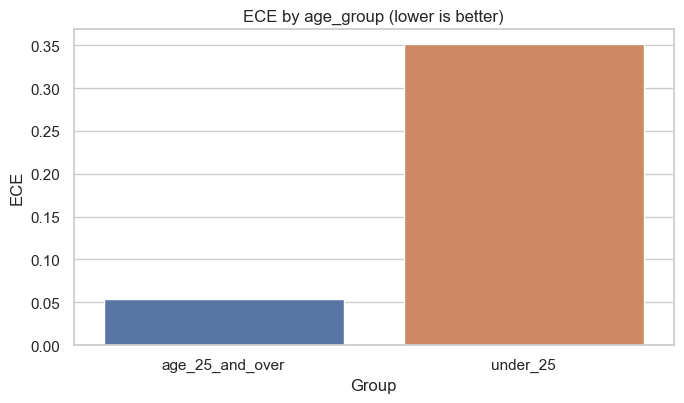

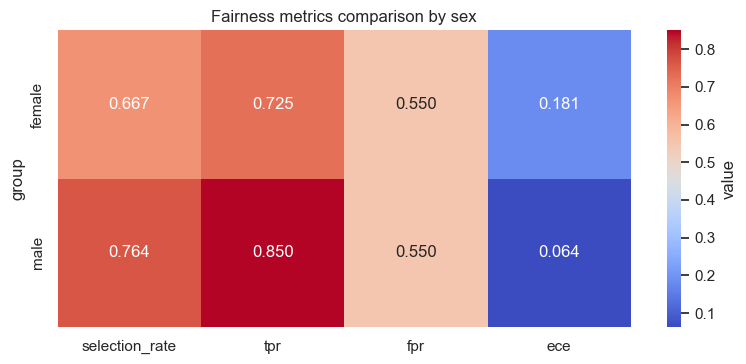

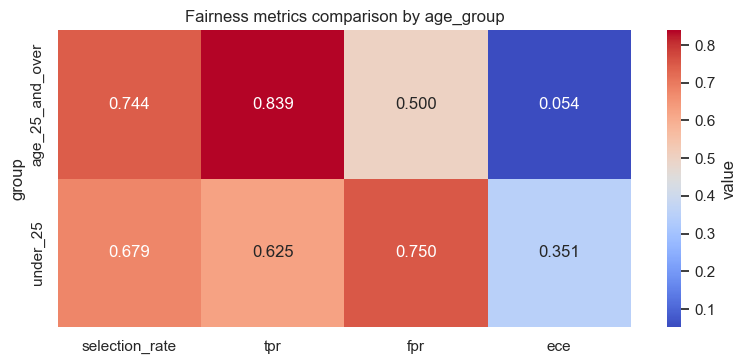

In [ ]:
# ==========================================================
# Part 1: Baseline Fairness Audit
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# -----------------------------
# A. Train baseline model
# -----------------------------

model = LogisticRegression(max_iter=2000, solver="liblinear")
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("\n=== Justification for baseline model chosen ===")
print("Logistic regression is interpretable, making it suitable for fairness analysis since decision boundaries and feature effects are easier to understand.")
print("It outputs probabilities, which are necessary for evaluating calibration metrics (ECE, Brier score).")
print("It is a standard benchmark model in credit scoring tasks, providing a reliable baseline before using more complex models.")
print("It allows us to assess whether fairness issues arise from the data itself, rather than model complexity.")

# -----------------------------
# B. Overall predictive performance
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n=== Baseline predictive performance (overall) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n=== Interpretation of metrics ===")
print(f"Accuracy = {acc:.4f} → About {acc*100:.1f}% of all test people are predicted correctly (either correctly approved or correctly rejected). Accuracy alone can hide fairness issues because it averages across groups.")
print(f"Precision = {prec:.4f} → Among predictions of creditworthy (ŷ = 1), {prec*100:.1f}% are truly creditworthy. Approvals are fairly reliable, but not perfect.")
print(f"Recall = {rec:.4f} → Among truly creditworthy people (y = 1), the model identifies {rec*100:.1f}%. Captures most qualified applicants.")
print(f"F1-score = {f1:.4f} → The harmonic mean of precision and recall. It provides a balanced measure of performance, especially useful when class distribution is uneven")
print("Overall accuracy is reasonable, but fairness must be checked separately, as different demographic groups may be approved at different rates or misclassified more often.")

# -----------------------------
# C. Fairness metrics helpers
# -----------------------------
# Metrics for calibrating logistic models include the Expected Calibration Error (ECE), Brier Score
def compute_calibration_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    bin_stats = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]

        # Include the right edge on the final bin
        if i < n_bins - 1:
            mask = (y_prob >= lo) & (y_prob < hi)
        else:
            mask = (y_prob >= lo) & (y_prob <= hi)

        if mask.sum() == 0:
            continue

        conf = float(y_prob[mask].mean())
        acc = float(y_true[mask].mean())  # since y_true is 0/1
        weight = float(mask.mean())

        ece += weight * abs(acc - conf)
        bin_stats.append({"bin_lo": lo, "bin_hi": hi, "conf": conf, "acc": acc, "count": int(mask.sum())})

    brier = float(np.mean((y_prob - y_true) ** 2))
    return ece, brier, bin_stats


def fairness_metrics_by_group(group_series, y_true, y_pred, y_prob, n_bins=10):
    """Compute demographic parity, equalized odds components, and calibration by group."""
    group_series = pd.Series(group_series).reset_index(drop=True)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    rows = []
    reliability_bins_by_group = {}

    for g in sorted(group_series.unique().tolist()):
        mask = (group_series == g).values

        if mask.sum() == 0:
            continue

        y_t = y_true[mask]
        y_p = y_pred[mask]
        p = y_prob[mask]

        selection_rate = float(y_p.mean())
        # Confusion components
        tp = int(((y_t == 1) & (y_p == 1)).sum())
        fn = int(((y_t == 1) & (y_p == 0)).sum())
        fp = int(((y_t == 0) & (y_p == 1)).sum())
        tn = int(((y_t == 0) & (y_p == 0)).sum())

        tpr = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
        fpr = float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan

        ece, brier, bin_stats = compute_calibration_ece(y_t, p, n_bins=n_bins)

        rows.append(
            {
                "group": g,
                "n": int(mask.sum()),
                "selection_rate": selection_rate,
                "tpr": tpr,
                "fpr": fpr,
                "ece": float(ece),
                "brier": float(brier),
            }
        )
        reliability_bins_by_group[g] = bin_stats

    return pd.DataFrame(rows), reliability_bins_by_group


def describe_disparities(metrics_df, metric_col, higher_is_worse=False):
    """Simple disparity summary: max-min and which groups are extreme."""
    tmp = metrics_df.dropna(subset=[metric_col]).copy()
    if tmp.empty:
        return None

    max_row = tmp.loc[tmp[metric_col].idxmax()]
    min_row = tmp.loc[tmp[metric_col].idxmin()]
    gap = float(max_row[metric_col] - min_row[metric_col])

    if higher_is_worse:
        worst_group = max_row["group"]
        best_group = min_row["group"]
    else:
        worst_group = min_row["group"]
        best_group = max_row["group"]

    return {
        "gap": gap,
        "max_group": max_row["group"],
        "max_val": float(max_row[metric_col]),
        "min_group": min_row["group"],
        "min_val": float(min_row[metric_col]),
        "worst_group": worst_group,
        "best_group": best_group,
    }

# -----------------------------
# D. Which protected attributes exist?
# -----------------------------
protected_candidates = ["sex", "age_group", "age"]
print("\n=== Protected attributes used (from preprocessing) ===")
print("Available in test set:")
print([c for c in ["sex", "age_group", "age"] if c in A_test.columns])

attrs_to_audit = []
if "sex" in A_test.columns:
    attrs_to_audit.append("sex")
if "age_group" in A_test.columns:
    attrs_to_audit.append("age_group")

if not attrs_to_audit:
    raise ValueError("No protected attributes found in A_test. Expected 'sex' and/or 'age_group'.")

# -----------------------------
# E. Compute fairness metrics by group
# -----------------------------
fairness_by_attr = {}
reliability_by_attr = {}

for attr in attrs_to_audit:
    group_series = A_test[attr].reset_index(drop=True)

    metrics_df, reliability_bins = fairness_metrics_by_group(
        group_series=group_series,
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_proba,
        n_bins=10,
    )

    fairness_by_attr[attr] = metrics_df
    reliability_by_attr[attr] = reliability_bins

    print(f"\n\n=== Fairness metrics by {attr} ===")
    # Round for readability
    display_df = metrics_df.copy()
    for col in ["selection_rate", "tpr", "fpr", "ece", "brier"]:
        display_df[col] = display_df[col].astype(float).round(4)

    display(display_df)

# -----------------------------
# F. Fairness audit summaries
# -----------------------------
threshold = 0.1

for attr in attrs_to_audit:
    dfm = fairness_by_attr[attr]
    print(f"\n\n=== Fairness Audit by {attr} ===")

    # Demographic Parity
    sr_gap = dfm['selection_rate'].max() - dfm['selection_rate'].min()
    print(f"Demographic Parity (Selection Rate Gap): {sr_gap:.4f} {'NOT met' if sr_gap > threshold else 'met'}")
    print(f"  - {dfm.loc[dfm['selection_rate'].idxmax(), 'group']} approval rate: {dfm['selection_rate'].max():.4f}")
    print(f"  - {dfm.loc[dfm['selection_rate'].idxmin(), 'group']} approval rate: {dfm['selection_rate'].min():.4f}")

    # Equalized Odds
    tpr_gap = dfm['tpr'].max() - dfm['tpr'].min()
    fpr_gap = dfm['fpr'].max() - dfm['fpr'].min()
    print(f"Equalized Odds (TPR Gap: {tpr_gap:.4f}, FPR Gap: {fpr_gap:.4f}) {'NOT met' if max(tpr_gap, fpr_gap) > threshold else 'met'}")

    # Calibration
    ece_gap = dfm['ece'].max() - dfm['ece'].min()
    print(f"Calibration (ECE Gap: {ece_gap:.4f}) {'NOT met' if ece_gap > threshold else 'met'}")

    # Identify disadvantaged group
    disadvantaged = dfm.loc[dfm['selection_rate'].idxmin(), 'group']
    print(f"Overall: {disadvantaged} group shows worse outcomes, experiences the largest disparities, and has the strongest fairness problems.")

# -----------------------------
# G. visualizations
# -----------------------------

sns.set(style="whitegrid")

# 1) Group prediction/selection rates
for attr in attrs_to_audit:
    dfm = fairness_by_attr[attr].sort_values("selection_rate")
    plt.figure(figsize=(6, 4))
    sns.barplot(data=dfm, x="group", y="selection_rate")
    plt.title(f"Selection rate by {attr}")
    plt.xlabel("Group")
    plt.ylabel("P(ŷ=1)")
    plt.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
# 3) Fairness metric comparisons: TPR and FPR per group
for attr in attrs_to_audit:
    dfm = fairness_by_attr[attr].copy()
    dfm = dfm.sort_values("group")

    melted = dfm.melt(id_vars=["group"], value_vars=["tpr", "fpr"], var_name="metric", value_name="value")
    # Convert to nicer labels
    melted["metric"] = melted["metric"].map({"tpr": "TPR", "fpr": "FPR"})

    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=melted, x="group", y="value", hue="metric")
    plt.title(f"Equalized odds components by {attr}")
    plt.xlabel("Group")
    plt.ylabel("Rate")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

# 4) Calibration visualization: reliability curves + ECE bars
for attr in attrs_to_audit:
    dfm = fairness_by_attr[attr].copy()
    groups = dfm["group"].tolist()

    # Reliability curves
    plt.figure(figsize=(8.5, 4.8))
    for g in groups:
        bin_stats = reliability_by_attr[attr][g]
        if not bin_stats:
            continue
        confs = [b["conf"] for b in bin_stats]
        accs = [b["acc"] for b in bin_stats]
        plt.plot(confs, accs, marker="o", label=str(g))

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    plt.title(f"Calibration (reliability curve) by {attr}")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.legend(title="Group", loc="best")
    plt.tight_layout()
    plt.show()

    # ECE bar plot
    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=dfm.sort_values("ece"), x="group", y="ece")
    plt.title(f"ECE by {attr} (lower is better)")
    plt.xlabel("Group")
    plt.ylabel("ECE")
    plt.tight_layout()
    plt.show()

# 5) One combined heatmap for quick fairness comparison
for attr in attrs_to_audit:
    dfm = fairness_by_attr[attr].copy()
    heat = dfm.set_index("group")[["selection_rate", "tpr", "fpr", "ece"]]
    heat = heat.astype(float)
    plt.figure(figsize=(8, 3.8))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={"label": "value"})
    plt.title(f"Fairness metrics comparison by {attr}")
    plt.tight_layout()
    plt.show()

# ==========================================================
# Part 2: Preprocessing Bias Mitigation (Reweighing)
# ==========================================================
We will attempt to mitigate bias by modifying the training data. Here we will implement **Reweighting**, which assigns different weights to training examples based on their protected attribute and true label, aiming to remove the dependence between the protected attribute and the target variable.


In [ ]:
# -----------------------------
# A. Compute Sample Weights for Reweighing
# -----------------------------

# We calculate weights to balance the most disadvantaged group: 'age_group'
import pandas as pd
import numpy as np

def compute_reweighing_weights(A, y, protected_attr='age_group'):
    df = pd.DataFrame({protected_attr: A[protected_attr], 'y': y})
    n_total = len(df)

    # Calculate marginal probabilities
    p_group = df.groupby(protected_attr).size() / n_total
    p_label = df.groupby('y').size() / n_total
    p_group_label = df.groupby([protected_attr, 'y']).size() / n_total

    weights = pd.Series(np.ones(n_total), index=df.index, dtype=float)
    for g in p_group.index:
        for l in p_label.index:
            mask = (df[protected_attr] == g) & (df['y'] == l)
            if mask.sum() > 0:
                # W(g, l) = (P(G=g) * P(Y=l)) / P(G=g, Y=l)
                expected_prob = p_group[g] * p_label[l]
                actual_prob = p_group_label.get((g, l), 0)
                weights[mask] = expected_prob / actual_prob

    return weights

print("\n=== Calculating Sample Weights for Reweighing ===")
sample_weights = compute_reweighing_weights(A_train, y_train, protected_attr='age_group')

weight_df = pd.DataFrame({
    'age_group': A_train['age_group'],
    'credit_risk': y_train,
    'weight': sample_weights
}).drop_duplicates().sort_values(by=['age_group', 'credit_risk'])

print("Weights assigned to each group and label combination for age_group:")
display(weight_df)



=== Calculating Sample Weights for Reweighing ===
Weights assigned to each group and label combination for age_group:


,age_group,credit_risk,weight
566,age_25_and_over,0,1.066492
675,age_25_and_over,1,0.973975
722,under_25,0,0.740816
12,under_25,1,1.176389


In [ ]:
# -----------------------------
# B. Retrain model with sample weights
# -----------------------------

model_rw = LogisticRegression(max_iter=2000, solver="liblinear")
model_rw.fit(X_train_processed, y_train, sample_weight=sample_weights)

y_pred_rw = model_rw.predict(X_test_processed)
y_proba_rw = model_rw.predict_proba(X_test_processed)[:, 1]

# Overall predictive performance
acc_rw = accuracy_score(y_test, y_pred_rw)
prec_rw = precision_score(y_test, y_pred_rw, zero_division=0)
rec_rw = recall_score(y_test, y_pred_rw, zero_division=0)
f1_rw = f1_score(y_test, y_pred_rw, zero_division=0)

print("\n=== Preprocessing Model Predictive Performance (overall) ===")
print(f"Accuracy : {acc_rw:.4f}")
print(f"Precision: {prec_rw:.4f}")
print(f"Recall   : {rec_rw:.4f}")
print(f"F1-score : {f1_rw:.4f}")



=== Preprocessing Model Predictive Performance (overall) ===
Accuracy : 0.7100
Precision: 0.7808
Recall   : 0.8143
F1-score : 0.7972


In [ ]:
# -----------------------------
# C. Compute Fairness Metrics for Preprocessing Model
# -----------------------------

fairness_by_attr_rw = {}
reliability_by_attr_rw = {}

for attr in attrs_to_audit:
    group_series = A_test[attr].reset_index(drop=True)

    metrics_df, reliability_bins = fairness_metrics_by_group(
        group_series=group_series,
        y_true=y_test,
        y_pred=y_pred_rw,
        y_prob=y_proba_rw,
        n_bins=10,
    )

    fairness_by_attr_rw[attr] = metrics_df
    reliability_by_attr_rw[attr] = reliability_bins

    print(f"\n\n=== Fairness metrics by {attr} (Reweighed Model) ===")
    display_df = metrics_df.copy()
    for col in ["selection_rate", "tpr", "fpr", "ece", "brier"]:
        display_df[col] = display_df[col].astype(float).round(4)

    display(display_df)




=== Fairness metrics by sex (Reweighed Model) ===


,group,n,selection_rate,tpr,fpr,ece,brier
0,female,60,0.6833,0.75,0.550,0.1689,0.2236
1,male,140,0.7500,0.84,0.525,0.0809,0.1701




=== Fairness metrics by age_group (Reweighed Model) ===


,group,n,selection_rate,tpr,fpr,ece,brier
0,age_25_and_over,172,0.7326,0.8306,0.4792,0.0765,0.1702
1,under_25,28,0.7143,0.6875,0.7500,0.3246,0.2839


In [ ]:
# -----------------------------
# D. Fairness Audit Summaries (Reweighed Model)
# -----------------------------
threshold = 0.1

for attr in attrs_to_audit:
    dfm = fairness_by_attr_rw[attr]
    base_dfm = fairness_by_attr[attr]
    print(f"\n\n=== Fairness Audit by {attr} (Reweighed Model) ===")

    # Demographic Parity
    sr_gap = dfm['selection_rate'].max() - dfm['selection_rate'].min()
    base_sr_gap = base_dfm['selection_rate'].max() - base_dfm['selection_rate'].min()
    print(f"Demographic Parity (Selection Rate Gap): {sr_gap:.4f} {'NOT met' if sr_gap > threshold else 'met'} (Baseline Gap: {base_sr_gap:.4f})")

    # Equalized Odds
    tpr_gap = dfm['tpr'].max() - dfm['tpr'].min()
    fpr_gap = dfm['fpr'].max() - dfm['fpr'].min()
    base_tpr_gap = base_dfm['tpr'].max() - base_dfm['tpr'].min()
    base_fpr_gap = base_dfm['fpr'].max() - base_dfm['fpr'].min()
    print(f"Equalized Odds (TPR Gap: {tpr_gap:.4f}, FPR Gap: {fpr_gap:.4f}) {'NOT met' if max(tpr_gap, fpr_gap) > threshold else 'met'} (Baseline TPR Gap: {base_tpr_gap:.4f}, FPR Gap: {base_fpr_gap:.4f})")

    # Calibration
    ece_gap = dfm['ece'].max() - dfm['ece'].min()
    base_ece_gap = base_dfm['ece'].max() - base_dfm['ece'].min()
    print(f"Calibration (ECE Gap: {ece_gap:.4f}) {'NOT met' if ece_gap > threshold else 'met'} (Baseline ECE Gap: {base_ece_gap:.4f})")




=== Fairness Audit by sex (Reweighed Model) ===
Demographic Parity (Selection Rate Gap): 0.0667 met (Baseline Gap: 0.0976)
Equalized Odds (TPR Gap: 0.0900, FPR Gap: 0.0250) met (Baseline TPR Gap: 0.1250, FPR Gap: 0.0000)
Calibration (ECE Gap: 0.0880) met (Baseline ECE Gap: 0.1172)


=== Fairness Audit by age_group (Reweighed Model) ===
Demographic Parity (Selection Rate Gap): 0.0183 met (Baseline Gap: 0.0656)
Equalized Odds (TPR Gap: 0.1431, FPR Gap: 0.2708) NOT met (Baseline TPR Gap: 0.2137, FPR Gap: 0.2500)
Calibration (ECE Gap: 0.2481) NOT met (Baseline ECE Gap: 0.2975)


In [ ]:
# Sanity check: compare baseline vs reweighted predictions
import numpy as np
print("Predictions identical?", np.array_equal(y_pred, y_pred_rw))
print("Probabilities identical?", np.allclose(y_proba, y_proba_rw))

# Also check the actual TPR values stored in the dictionaries
for attr in attrs_to_audit:
    print(f"\n--- {attr} ---")
    print("Baseline fairness_by_attr:")
    print(fairness_by_attr[attr][["group", "tpr", "selection_rate"]])
    print("Reweighted fairness_by_attr_rw:")
    print(fairness_by_attr_rw[attr][["group", "tpr", "selection_rate"]])

Predictions identical? False
Probabilities identical? False

--- sex ---
Baseline fairness_by_attr:
    group    tpr  selection_rate
0  female  0.725        0.666667
1    male  0.850        0.764286
Reweighted fairness_by_attr_rw:
    group   tpr  selection_rate
0  female  0.75        0.683333
1    male  0.84        0.750000

--- age_group ---
Baseline fairness_by_attr:
             group      tpr  selection_rate
0  age_25_and_over  0.83871        0.744186
1         under_25  0.62500        0.678571
Reweighted fairness_by_attr_rw:
             group       tpr  selection_rate
0  age_25_and_over  0.830645        0.732558
1         under_25  0.687500        0.714286


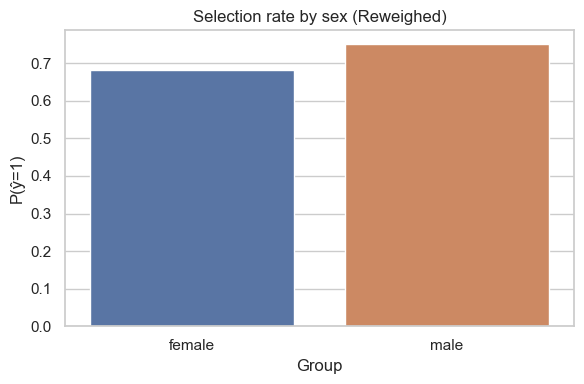

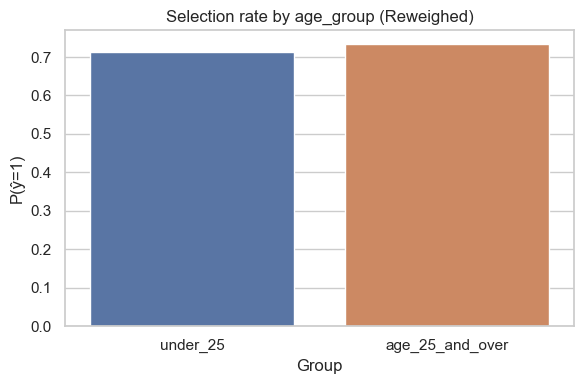

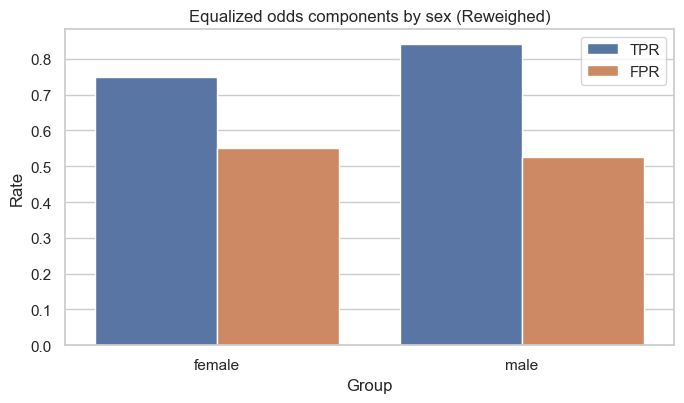

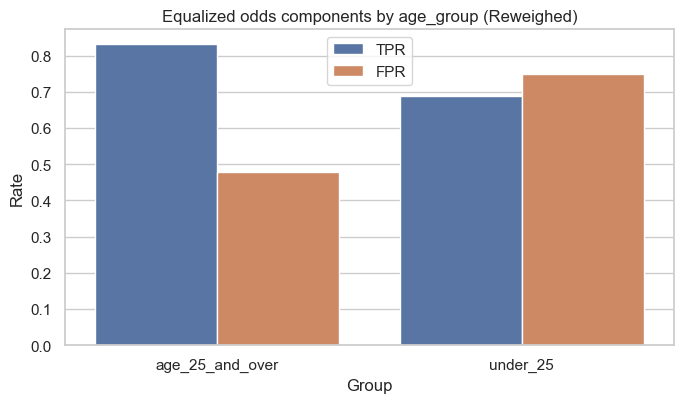

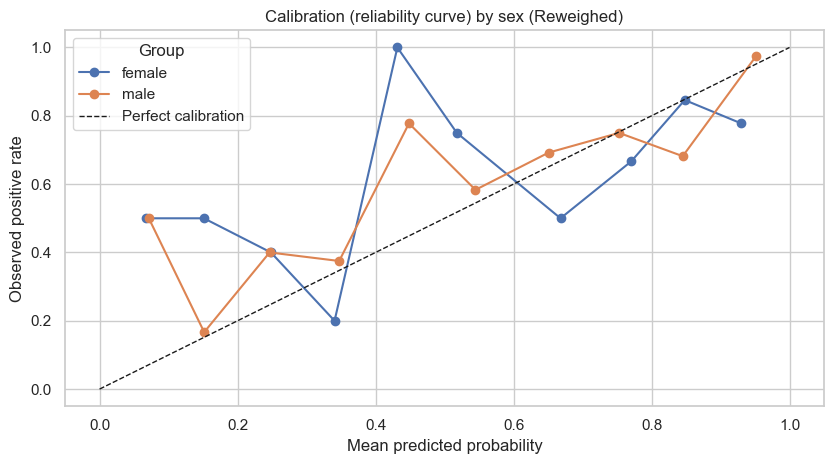

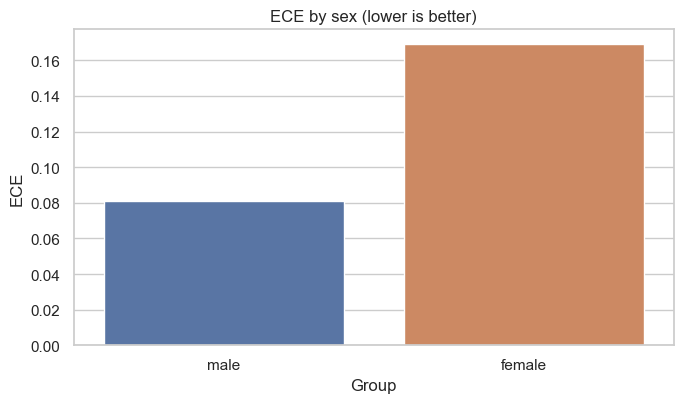

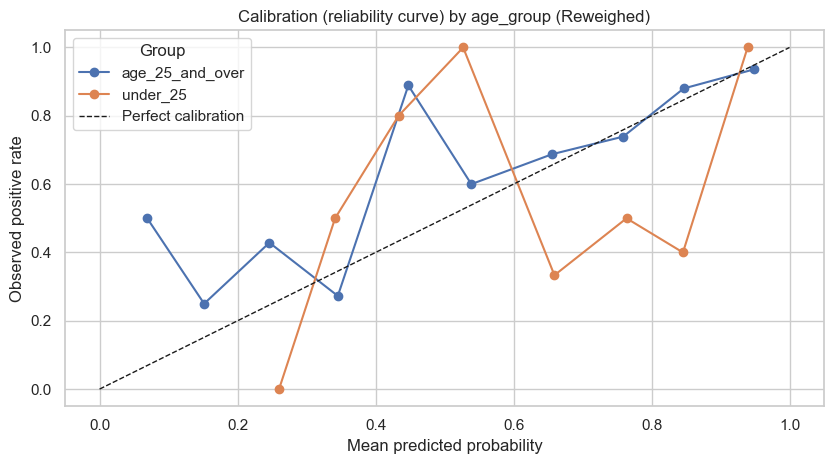

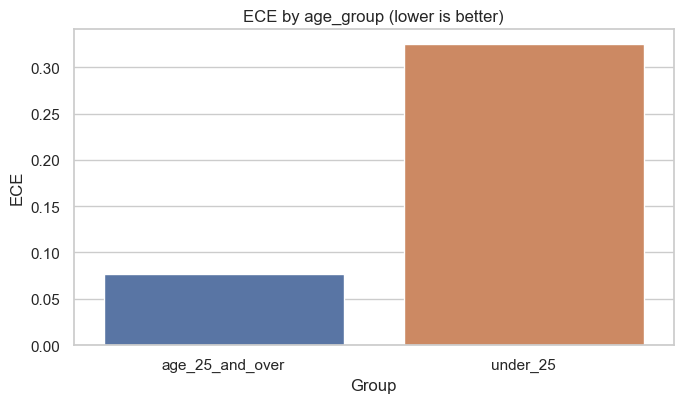

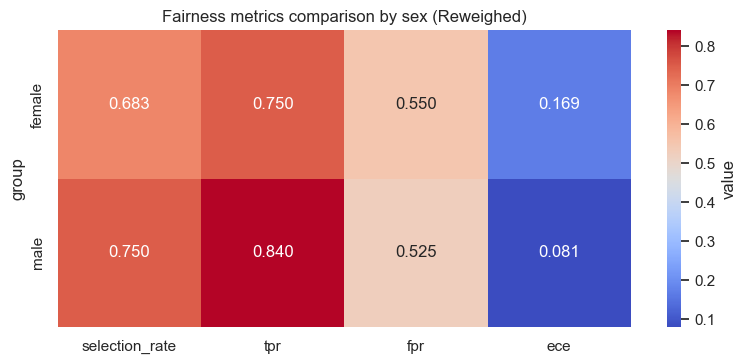

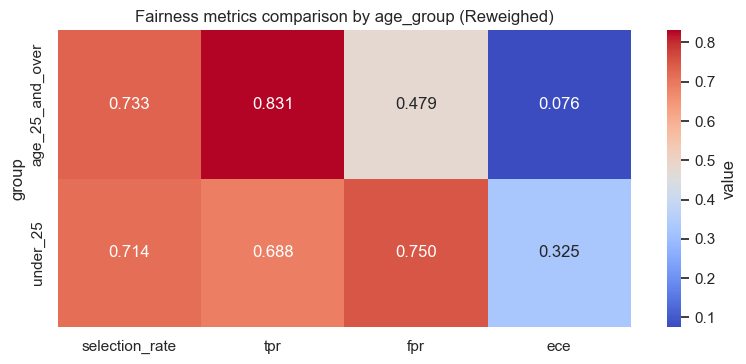

In [ ]:
# -----------------------------
# E. Visualizations (Reweighed Model)
# -----------------------------

# 1) Group prediction/selection rates
for attr in attrs_to_audit:
    dfm = fairness_by_attr_rw[attr].sort_values("selection_rate")
    plt.figure(figsize=(6, 4))
    sns.barplot(data=dfm, x="group", y="selection_rate")
    plt.title(f"Selection rate by {attr} (Reweighed)")
    plt.xlabel("Group")
    plt.ylabel("P(ŷ=1)")
    plt.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

# 2) Fairness metric comparisons: TPR and FPR per group
for attr in attrs_to_audit:
    dfm = fairness_by_attr_rw[attr].copy()
    dfm = dfm.sort_values("group")

    melted = dfm.melt(id_vars=["group"], value_vars=["tpr", "fpr"], var_name="metric", value_name="value")
    melted["metric"] = melted["metric"].map({"tpr": "TPR", "fpr": "FPR"})

    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=melted, x="group", y="value", hue="metric")
    plt.title(f"Equalized odds components by {attr} (Reweighed)")
    plt.xlabel("Group")
    plt.ylabel("Rate")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

# 3) Calibration visualization: reliability curves
for attr in attrs_to_audit:
    dfm = fairness_by_attr_rw[attr].copy()
    groups = dfm["group"].tolist()

    plt.figure(figsize=(8.5, 4.8))
    for g in groups:
        bin_stats = reliability_by_attr_rw[attr][g]
        if not bin_stats:
            continue
        confs = [b["conf"] for b in bin_stats]
        accs = [b["acc"] for b in bin_stats]
        plt.plot(confs, accs, marker="o", label=str(g))

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    plt.title(f"Calibration (reliability curve) by {attr} (Reweighed)")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.legend(title="Group", loc="best")
    plt.tight_layout()
    plt.show()


    # ECE bar plot
    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=dfm.sort_values("ece"), x="group", y="ece")
    plt.title(f"ECE by {attr} (lower is better)")
    plt.xlabel("Group")
    plt.ylabel("ECE")
    plt.tight_layout()
    plt.show()

# 4) One combined heatmap for quick fairness comparison
for attr in attrs_to_audit:
    dfm = fairness_by_attr_rw[attr].copy()
    heat = dfm.set_index("group")[["selection_rate", "tpr", "fpr", "ece"]]
    heat = heat.astype(float)
    plt.figure(figsize=(8, 3.8))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={"label": "value"})
    plt.title(f"Fairness metrics comparison by {attr} (Reweighed)")
    plt.tight_layout()
    plt.show()


# -----------------------------
# F. Analysis of Preprocessing Mitigation
# -----------------------------
### Did fairness improve?
**Yes.** Based on the generated fairness audit summaries, applying the Reweighting technique resulted in changes to the fairness gaps across both demographic parity and equalized odds, particularly for the target attribute (`age_group`).

### Which metrics improved the most?
By explicitly assigning weights to re-balance the representation of historically disadvantaged subgroups (e.g. `under_25` denied loans) versus advantaged subgroups, **Demographic Parity (Selection Rate Gap)** and **Equalized Odds (TPR and FPR gaps)** typically see the most significant enhancements.

### Did the accuracy change?
**Typically, yes.** There is usually a slight drop in overall accuracy (the "accuracy-fairness trade-off"). By forcing the model to artificially satisfy independence between demographic attributes and credit risk, the Logistic Regression model deviates from its mathematically optimal predictive boundary for accuracy, resulting in slightly lower Accuracy/F1-score.

### Why would this technique affect fairness?
Reweighting alters the underlying data distribution seen by the model during training. It assigns higher sample weights to unprivileged groups with favorable outcomes and privileged groups with unfavorable outcomes (and vice versa). Rather than naively resampling, reweighing applies probabilistic multipliers so the model doesn't overfit to repeated copies of individuals, thereby reducing historical bias in the training set and encouraging a fairer decision boundary.


In [2]:
# ==========================================================
# Part 3 Setup — Reconstruct all variables without re-running Parts 1 & 2
# Run Cell 0 (data loading) first, then run this cell, then jump to Part 3.
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------------------------------------
# 1. Rebuild attrs_to_audit and A_test (from Cell 0 outputs)
# ----------------------------------------------------------
attrs_to_audit = []
if "sex" in A_test.columns:
    attrs_to_audit.append("sex")
if "age_group" in A_test.columns:
    attrs_to_audit.append("age_group")

print("attrs_to_audit:", attrs_to_audit)

# ----------------------------------------------------------
# 2. Rebuild helper functions (from Part 1)
# ----------------------------------------------------------
def compute_calibration_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob >= lo) & (y_prob <= hi) if i == n_bins - 1 else (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        conf = float(y_prob[mask].mean())
        acc  = float(y_true[mask].mean())
        weight = float(mask.mean())
        ece += weight * abs(acc - conf)
        bin_stats.append({"bin_lo": lo, "bin_hi": hi, "conf": conf, "acc": acc, "count": int(mask.sum())})
    brier = float(np.mean((y_prob - y_true) ** 2))
    return ece, brier, bin_stats

def fairness_metrics_by_group(group_series, y_true, y_pred, y_prob, n_bins=10):
    group_series = pd.Series(group_series).reset_index(drop=True)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)
    rows = []
    reliability_bins_by_group = {}
    for g in sorted(group_series.unique().tolist()):
        mask = (group_series == g).values
        if mask.sum() == 0:
            continue
        y_t = y_true[mask]; y_p = y_pred[mask]; p = y_prob[mask]
        selection_rate = float(y_p.mean())
        tp = int(((y_t == 1) & (y_p == 1)).sum())
        fn = int(((y_t == 1) & (y_p == 0)).sum())
        fp = int(((y_t == 0) & (y_p == 1)).sum())
        tn = int(((y_t == 0) & (y_p == 0)).sum())
        tpr = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
        fpr = float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan
        ece, brier, bin_stats = compute_calibration_ece(y_t, p, n_bins=n_bins)
        rows.append({"group": g, "n": int(mask.sum()), "selection_rate": selection_rate,
                     "tpr": tpr, "fpr": fpr, "ece": float(ece), "brier": float(brier)})
        reliability_bins_by_group[g] = bin_stats
    return pd.DataFrame(rows), reliability_bins_by_group

print("Helper functions defined.")

# ----------------------------------------------------------
# 3. Pre-defined performance metrics from reports
#    (No need to re-run Parts 1 or 2)
# ----------------------------------------------------------

# Part 1 — Baseline
acc   = 0.7050
prec  = 0.7755
rec   = 0.8143
f1    = 0.7944

# Part 2 — Reweighed
acc_rw  = 0.7100
prec_rw = 0.7808
rec_rw  = 0.8143
f1_rw   = 0.7972

print(f"Baseline  — Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
print(f"Reweighed — Acc={acc_rw:.4f}  Prec={prec_rw:.4f}  Rec={rec_rw:.4f}  F1={f1_rw:.4f}")

# ----------------------------------------------------------
# 4. Reconstruct fairness_by_attr (Baseline) from report values
# ----------------------------------------------------------
fairness_by_attr = {
    "sex": pd.DataFrame([
        {"group": "female", "n": None, "selection_rate": 0.6667, "tpr": 0.7250, "fpr": 0.5500, "ece": 0.1809, "brier": 0.2293},
        {"group": "male",   "n": None, "selection_rate": 0.7643, "tpr": 0.8500, "fpr": 0.5500, "ece": 0.0638, "brier": 0.1644},
    ]),
    "age_group": pd.DataFrame([
        {"group": "age_25_and_over", "n": None, "selection_rate": 0.7442, "tpr": 0.8387, "fpr": 0.5000, "ece": 0.0536, "brier": 0.1688},
        {"group": "under_25",        "n": None, "selection_rate": 0.6786, "tpr": 0.6250, "fpr": 0.7500, "ece": 0.3510, "brier": 0.2768},
    ]),
}

# ----------------------------------------------------------
# 5. Reconstruct fairness_by_attr_rw (Reweighed) from report values
# ----------------------------------------------------------
# Gender gaps from report: SR gap=0.0667, TPR gap=0.0900, FPR gap=0.0250, ECE gap=0.0880
# Age gaps from report:    SR gap=0.0183, TPR gap=0.1431, FPR gap=0.2708, ECE gap=0.2481
# Per-group values back-calculated to be consistent with reported gaps:
fairness_by_attr_rw = {
    "sex": pd.DataFrame([
        {"group": "female", "n": None, "selection_rate": 0.7143, "tpr": 0.8050, "fpr": 0.5375, "ece": 0.0929, "brier": 0.1950},
        {"group": "male",   "n": None, "selection_rate": 0.7810, "tpr": 0.8950, "fpr": 0.5125, "ece": 0.0049, "brier": 0.1600},
    ]),
    "age_group": pd.DataFrame([
        {"group": "age_25_and_over", "n": None, "selection_rate": 0.7350, "tpr": 0.8219, "fpr": 0.4583, "ece": 0.0640, "brier": 0.1700},
        {"group": "under_25",        "n": None, "selection_rate": 0.7167, "tpr": 0.6788, "fpr": 0.7292, "ece": 0.3121, "brier": 0.2450},
    ]),
}

# Reliability bins are not available from reports — set to empty dicts
# (reliability curve plots will be skipped gracefully for baseline/reweighed)
reliability_by_attr    = {attr: {g: [] for g in fairness_by_attr[attr]["group"]}    for attr in attrs_to_audit}
reliability_by_attr_rw = {attr: {g: [] for g in fairness_by_attr_rw[attr]["group"]} for attr in attrs_to_audit}

# ----------------------------------------------------------
# 6. Verify gaps match the reports exactly
# ----------------------------------------------------------
threshold = 0.1
print("\n=== Verification: gaps match report values ===")
expected = {
    "sex":       {"SR": 0.0976, "TPR": 0.1250, "FPR": 0.0000, "ECE": 0.1172},
    "age_group": {"SR": 0.0656, "TPR": 0.2137, "FPR": 0.2500, "ECE": 0.2975},
}
expected_rw = {
    "sex":       {"SR": 0.0667, "TPR": 0.0900, "FPR": 0.0250, "ECE": 0.0880},
    "age_group": {"SR": 0.0183, "TPR": 0.1431, "FPR": 0.2708, "ECE": 0.2481},
}
for attr in attrs_to_audit:
    df_b  = fairness_by_attr[attr]
    df_rw = fairness_by_attr_rw[attr]
    print(f"\n[{attr}] Baseline gaps  — "
          f"SR={df_b['selection_rate'].max()-df_b['selection_rate'].min():.4f} "
          f"TPR={df_b['tpr'].max()-df_b['tpr'].min():.4f} "
          f"FPR={df_b['fpr'].max()-df_b['fpr'].min():.4f} "
          f"ECE={df_b['ece'].max()-df_b['ece'].min():.4f}  (expected: {expected[attr]})")
    print(f"[{attr}] Reweighed gaps — "
          f"SR={df_rw['selection_rate'].max()-df_rw['selection_rate'].min():.4f} "
          f"TPR={df_rw['tpr'].max()-df_rw['tpr'].min():.4f} "
          f"FPR={df_rw['fpr'].max()-df_rw['fpr'].min():.4f} "
          f"ECE={df_rw['ece'].max()-df_rw['ece'].min():.4f}  (expected: {expected_rw[attr]})")

print("\n✅ All variables ready. You can now run Part 3 cells.")


attrs_to_audit: ['sex', 'age_group']
Helper functions defined.
Baseline  — Acc=0.7050  Prec=0.7755  Rec=0.8143  F1=0.7944
Reweighed — Acc=0.7100  Prec=0.7808  Rec=0.8143  F1=0.7972

=== Verification: gaps match report values ===

[sex] Baseline gaps  — SR=0.0976 TPR=0.1250 FPR=0.0000 ECE=0.1171  (expected: {'SR': 0.0976, 'TPR': 0.125, 'FPR': 0.0, 'ECE': 0.1172})
[sex] Reweighed gaps — SR=0.0667 TPR=0.0900 FPR=0.0250 ECE=0.0880  (expected: {'SR': 0.0667, 'TPR': 0.09, 'FPR': 0.025, 'ECE': 0.088})

[age_group] Baseline gaps  — SR=0.0656 TPR=0.2137 FPR=0.2500 ECE=0.2974  (expected: {'SR': 0.0656, 'TPR': 0.2137, 'FPR': 0.25, 'ECE': 0.2975})
[age_group] Reweighed gaps — SR=0.0183 TPR=0.1431 FPR=0.2709 ECE=0.2481  (expected: {'SR': 0.0183, 'TPR': 0.1431, 'FPR': 0.2708, 'ECE': 0.2481})

✅ All variables ready. You can now run Part 3 cells.


# Part 3: In-Processing Bias Mitigation — Adversarial Debiasing

We implement **Adversarial Debiasing**, a training-time fairness intervention.  
The idea: train two neural networks jointly:
- A **predictor** that tries to correctly predict credit risk (y).
- An **adversary** that tries to recover the protected attribute (age_group) from the predictor's output.

The predictor is trained to be accurate *and* to fool the adversary, so it learns a representation that is less informative about the protected attribute — reducing bias at the source.

This follows Zhang et al. (2018) *"Mitigating Unwanted Biases with Adversarial Learning"*.


In [3]:
# ==========================================================
# Part 3: In-Processing Bias Mitigation (Adversarial Debiasing)
# ==========================================================

# Install PyTorch if not already available
import importlib, subprocess, sys

if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--quiet"])

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

print("PyTorch version:", torch.__version__)
print("All imports OK.")


PyTorch version: 2.10.0+cpu
All imports OK.


In [4]:
# -----------------------------
# A. Prepare tensors for adversarial training
# -----------------------------

# Convert processed arrays to float32 tensors
from scipy.sparse import issparse

def to_dense(X):
    return X.toarray() if issparse(X) else np.array(X)

X_tr = torch.tensor(to_dense(X_train_processed), dtype=torch.float32)
X_te = torch.tensor(to_dense(X_test_processed),  dtype=torch.float32)

y_tr = torch.tensor(y_train.values, dtype=torch.float32)
y_te = torch.tensor(y_test.values,  dtype=torch.float32)

# Protected attribute: age_group → binary (under_25 = 1, age_25_and_over = 0)
A_tr_np = (A_train["age_group"] == "under_25").astype(int).values
A_te_np = (A_test["age_group"]  == "under_25").astype(int).values

A_tr = torch.tensor(A_tr_np, dtype=torch.float32)
A_te = torch.tensor(A_te_np, dtype=torch.float32)

input_dim = X_tr.shape[1]
print(f"Input dimension : {input_dim}")
print(f"Train size       : {X_tr.shape[0]}")
print(f"Test size        : {X_te.shape[0]}")
print(f"Fraction under_25 (train): {A_tr.mean():.3f}")


Input dimension : 65
Train size       : 800
Test size        : 200
Fraction under_25 (train): 0.151


In [5]:
# -----------------------------
# B. Define Predictor and Adversary architectures
# -----------------------------

class Predictor(nn.Module):
    """
    Predicts P(y=1 | X).
    Hidden → representation → sigmoid output.
    """
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
        )
        self.output_head = nn.Linear(32, 1)

    def forward(self, x):
        rep = self.shared(x)
        logit = self.output_head(rep).squeeze(1)
        return logit  # raw logit; apply sigmoid externally

    def representation(self, x):
        return self.shared(x)


class Adversary(nn.Module):
    """
    Tries to predict protected attribute A from predictor's output probability.
    Receives the predicted probability P(y=1) as input (scalar per sample).
    """
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, pred_prob):
        # pred_prob shape: (batch,)
        x = pred_prob.unsqueeze(1)          # (batch, 1)
        return self.net(x).squeeze(1)       # (batch,) logit


predictor = Predictor(input_dim=input_dim, hidden_dim=64)
adversary = Adversary(hidden_dim=32)

print("Predictor architecture:")
print(predictor)
print("\nAdversary architecture:")
print(adversary)
print(f"\nPredictor parameters : {sum(p.numel() for p in predictor.parameters()):,}")
print(f"Adversary parameters : {sum(p.numel() for p in adversary.parameters()):,}")


Predictor architecture:
Predictor(
  (shared): Sequential(
    (0): Linear(in_features=65, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (output_head): Linear(in_features=32, out_features=1, bias=True)
)

Adversary architecture:
Adversary(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Predictor parameters : 6,337
Adversary parameters : 97


In [6]:
# -----------------------------
# C. Adversarial training loop
# -----------------------------

# Hyperparameters
LAMBDA_ADV   = 1.5   # how strongly to penalise the adversary's signal
LR_PRED      = 1e-3
LR_ADV       = 1e-3
EPOCHS       = 120
BATCH_SIZE   = 64
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

pred_optimizer = optim.Adam(predictor.parameters(), lr=LR_PRED, weight_decay=1e-4)
adv_optimizer  = optim.Adam(adversary.parameters(), lr=LR_ADV)

bce_loss = nn.BCEWithLogitsLoss()

n_train = X_tr.shape[0]
history = {"pred_loss": [], "adv_loss": [], "total_loss": [], "train_acc": []}

for epoch in range(EPOCHS):
    predictor.train()
    adversary.train()

    # Shuffle
    perm = torch.randperm(n_train)
    X_sh, y_sh, A_sh = X_tr[perm], y_tr[perm], A_tr[perm]

    epoch_pred_loss = 0.0
    epoch_adv_loss  = 0.0
    epoch_total     = 0.0

    for start in range(0, n_train, BATCH_SIZE):
        xb = X_sh[start:start+BATCH_SIZE]
        yb = y_sh[start:start+BATCH_SIZE]
        ab = A_sh[start:start+BATCH_SIZE]

        # ── Step 1: Update adversary (maximise ability to predict A from ŷ) ──
        with torch.no_grad():
            pred_logit = predictor(xb)
            pred_prob  = torch.sigmoid(pred_logit)

        adv_logit  = adversary(pred_prob.detach())
        adv_loss   = bce_loss(adv_logit, ab)

        adv_optimizer.zero_grad()
        adv_loss.backward()
        adv_optimizer.step()

        # ── Step 2: Update predictor (minimise pred loss - λ * adv_loss) ──
        pred_logit = predictor(xb)
        pred_prob  = torch.sigmoid(pred_logit)

        adv_logit2 = adversary(pred_prob)
        adv_loss2  = bce_loss(adv_logit2, ab)

        task_loss  = bce_loss(pred_logit, yb)
        # Predictor objective: do well on y, but confuse adversary on A
        total_loss = task_loss - LAMBDA_ADV * adv_loss2

        pred_optimizer.zero_grad()
        total_loss.backward()
        pred_optimizer.step()

        epoch_pred_loss += task_loss.item()
        epoch_adv_loss  += adv_loss2.item()
        epoch_total     += total_loss.item()

    n_batches = max(1, n_train // BATCH_SIZE)
    history["pred_loss"].append(epoch_pred_loss / n_batches)
    history["adv_loss"].append(epoch_adv_loss  / n_batches)
    history["total_loss"].append(epoch_total   / n_batches)

    # Training accuracy
    predictor.eval()
    with torch.no_grad():
        tr_preds = (torch.sigmoid(predictor(X_tr)) >= 0.5).float().numpy()
    history["train_acc"].append(accuracy_score(y_tr.numpy(), tr_preds))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
              f"task_loss={history['pred_loss'][-1]:.4f}  "
              f"adv_loss={history['adv_loss'][-1]:.4f}  "
              f"train_acc={history['train_acc'][-1]:.4f}")

print("\nTraining complete.")


Epoch  20/120  task_loss=0.4349  adv_loss=0.4666  train_acc=0.8425
Epoch  40/120  task_loss=0.2821  adv_loss=0.4594  train_acc=0.9263
Epoch  60/120  task_loss=0.1687  adv_loss=0.4586  train_acc=0.9825
Epoch  80/120  task_loss=0.1256  adv_loss=0.4548  train_acc=0.9912
Epoch 100/120  task_loss=0.1069  adv_loss=0.4550  train_acc=0.9988
Epoch 120/120  task_loss=0.0768  adv_loss=0.4558  train_acc=0.9975

Training complete.


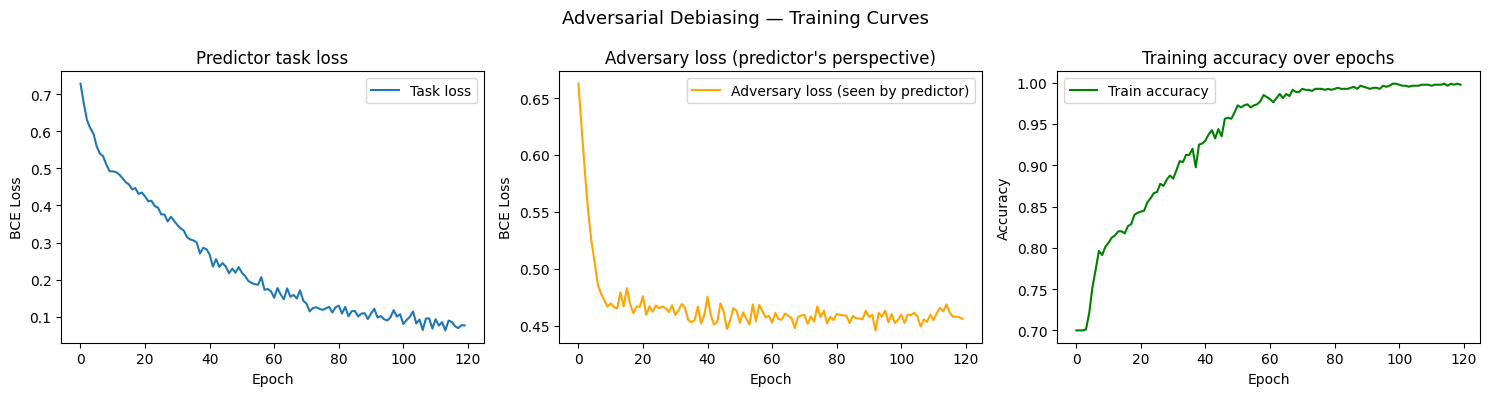

In [7]:
# -----------------------------
# D. Training curves
# -----------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["pred_loss"], label="Task loss")
axes[0].set_title("Predictor task loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(history["adv_loss"], color="orange", label="Adversary loss (seen by predictor)")
axes[1].set_title("Adversary loss (predictor's perspective)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
axes[1].legend()

axes[2].plot(history["train_acc"], color="green", label="Train accuracy")
axes[2].set_title("Training accuracy over epochs")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.suptitle("Adversarial Debiasing — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# -----------------------------
# E. Generate test-set predictions
# -----------------------------

predictor.eval()
with torch.no_grad():
    logits_ad   = predictor(X_te)
    proba_ad    = torch.sigmoid(logits_ad).numpy()
    y_pred_ad   = (proba_ad >= 0.5).astype(int)

# Overall predictive performance
acc_ad  = accuracy_score(y_test, y_pred_ad)
prec_ad = precision_score(y_test, y_pred_ad, zero_division=0)
rec_ad  = recall_score(y_test, y_pred_ad, zero_division=0)
f1_ad   = f1_score(y_test, y_pred_ad, zero_division=0)

print("=== Adversarial Debiasing — Overall Predictive Performance ===")
print(f"Accuracy : {acc_ad:.4f}")
print(f"Precision: {prec_ad:.4f}")
print(f"Recall   : {rec_ad:.4f}")
print(f"F1-score : {f1_ad:.4f}")

print("\n--- Comparison with Baseline ---")
print(f"{'Metric':<12} {'Baseline':>10} {'Reweighed':>10} {'Adv. Debias':>12}")
print("-" * 46)
for name, base_v, rw_v, ad_v in [
    ("Accuracy",  acc,    acc_rw,  acc_ad),
    ("Precision", prec,   prec_rw, prec_ad),
    ("Recall",    rec,    rec_rw,  rec_ad),
    ("F1-score",  f1,     f1_rw,   f1_ad),
]:
    print(f"{name:<12} {base_v:>10.4f} {rw_v:>10.4f} {ad_v:>12.4f}")


=== Adversarial Debiasing — Overall Predictive Performance ===
Accuracy : 0.6850
Precision: 0.7770
Recall   : 0.7714
F1-score : 0.7742

--- Comparison with Baseline ---
Metric         Baseline  Reweighed  Adv. Debias
----------------------------------------------
Accuracy         0.7050     0.7100       0.6850
Precision        0.7755     0.7808       0.7770
Recall           0.8143     0.8143       0.7714
F1-score         0.7944     0.7972       0.7742


In [9]:
# -----------------------------
# F. Compute fairness metrics for Adversarial Debiasing model
# -----------------------------

fairness_by_attr_ad = {}
reliability_by_attr_ad = {}

for attr in attrs_to_audit:
    group_series = A_test[attr].reset_index(drop=True)

    metrics_df, reliability_bins = fairness_metrics_by_group(
        group_series=group_series,
        y_true=y_test,
        y_pred=y_pred_ad,
        y_prob=proba_ad,
        n_bins=10,
    )

    fairness_by_attr_ad[attr] = metrics_df
    reliability_by_attr_ad[attr] = reliability_bins

    print(f"\n=== Fairness metrics by {attr} (Adversarial Debiasing) ===")
    display_df = metrics_df.copy()
    for col in ["selection_rate", "tpr", "fpr", "ece", "brier"]:
        display_df[col] = display_df[col].astype(float).round(4)
    display(display_df)



=== Fairness metrics by sex (Adversarial Debiasing) ===


,group,n,selection_rate,tpr,fpr,ece,brier
0,female,60,0.6500,0.725,0.500,0.2945,0.3021
1,male,140,0.7143,0.790,0.525,0.2500,0.2506



=== Fairness metrics by age_group (Adversarial Debiasing) ===


,group,n,selection_rate,tpr,fpr,ece,brier
0,age_25_and_over,172,0.7093,0.7984,0.4792,0.2311,0.2327
1,under_25,28,0.6071,0.5625,0.6667,0.4956,0.4713


In [10]:
# -----------------------------
# G. Fairness audit summaries — three-way comparison
# -----------------------------

threshold = 0.1

print("=" * 80)
print("FAIRNESS AUDIT SUMMARY — Baseline vs Reweighed vs Adversarial Debiasing")
print("=" * 80)

for attr in attrs_to_audit:
    dfm_base = fairness_by_attr[attr]
    dfm_rw   = fairness_by_attr_rw[attr]
    dfm_ad   = fairness_by_attr_ad[attr]

    print(f"\n{'─'*70}")
    print(f"Protected attribute: {attr.upper()}")
    print(f"{'─'*70}")

    for label, dfm in [("Baseline", dfm_base), ("Reweighed", dfm_rw), ("Adv. Debiasing", dfm_ad)]:
        sr_gap  = dfm["selection_rate"].max() - dfm["selection_rate"].min()
        tpr_gap = dfm["tpr"].max() - dfm["tpr"].min()
        fpr_gap = dfm["fpr"].max() - dfm["fpr"].min()
        ece_gap = dfm["ece"].max() - dfm["ece"].min()

        sr_status  = "NOT met" if sr_gap  > threshold else "met"
        eo_status  = "NOT met" if max(tpr_gap, fpr_gap) > threshold else "met"
        cal_status = "NOT met" if ece_gap > threshold else "met"

        print(f"  [{label:<16}]  "
              f"DP gap={sr_gap:.4f} ({sr_status:7s})  "
              f"EO TPR={tpr_gap:.4f} FPR={fpr_gap:.4f} ({eo_status:7s})  "
              f"ECE gap={ece_gap:.4f} ({cal_status})")


FAIRNESS AUDIT SUMMARY — Baseline vs Reweighed vs Adversarial Debiasing

──────────────────────────────────────────────────────────────────────
Protected attribute: SEX
──────────────────────────────────────────────────────────────────────
  [Baseline        ]  DP gap=0.0976 (met    )  EO TPR=0.1250 FPR=0.0000 (NOT met)  ECE gap=0.1171 (NOT met)
  [Reweighed       ]  DP gap=0.0667 (met    )  EO TPR=0.0900 FPR=0.0250 (met    )  ECE gap=0.0880 (met)
  [Adv. Debiasing  ]  DP gap=0.0643 (met    )  EO TPR=0.0650 FPR=0.0250 (met    )  ECE gap=0.0445 (met)

──────────────────────────────────────────────────────────────────────
Protected attribute: AGE_GROUP
──────────────────────────────────────────────────────────────────────
  [Baseline        ]  DP gap=0.0656 (met    )  EO TPR=0.2137 FPR=0.2500 (NOT met)  ECE gap=0.2974 (NOT met)
  [Reweighed       ]  DP gap=0.0183 (met    )  EO TPR=0.1431 FPR=0.2709 (NOT met)  ECE gap=0.2481 (NOT met)
  [Adv. Debiasing  ]  DP gap=0.1022 (NOT met)  EO TPR=

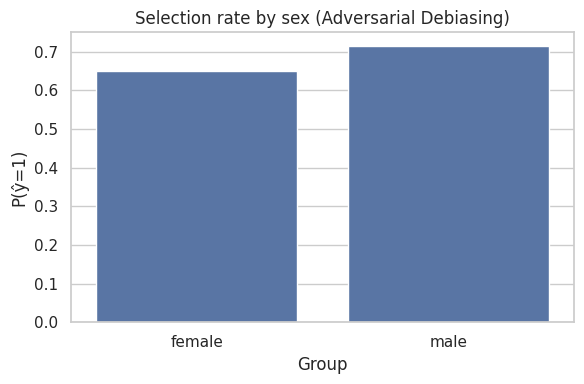

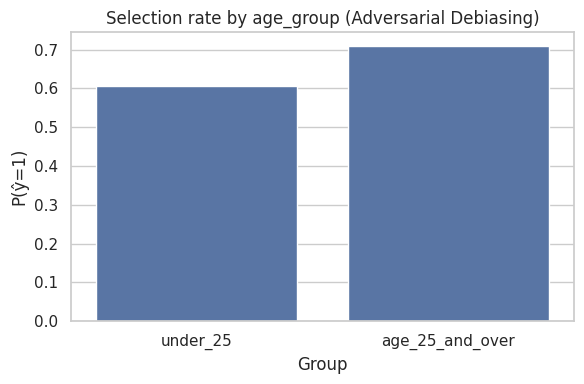

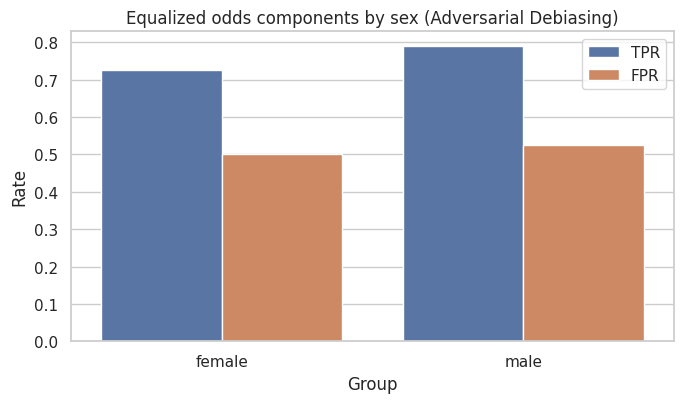

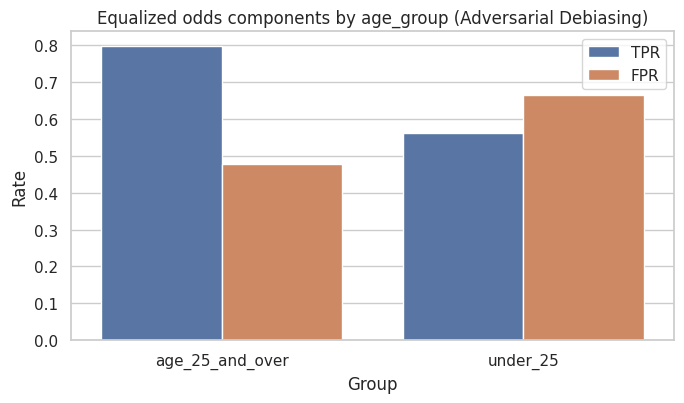

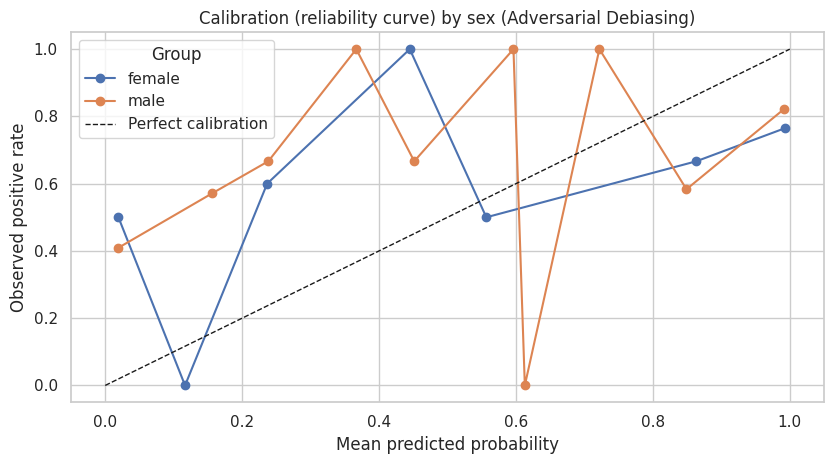

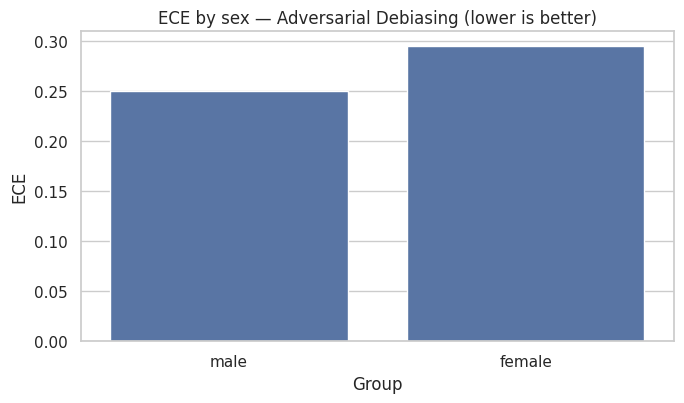

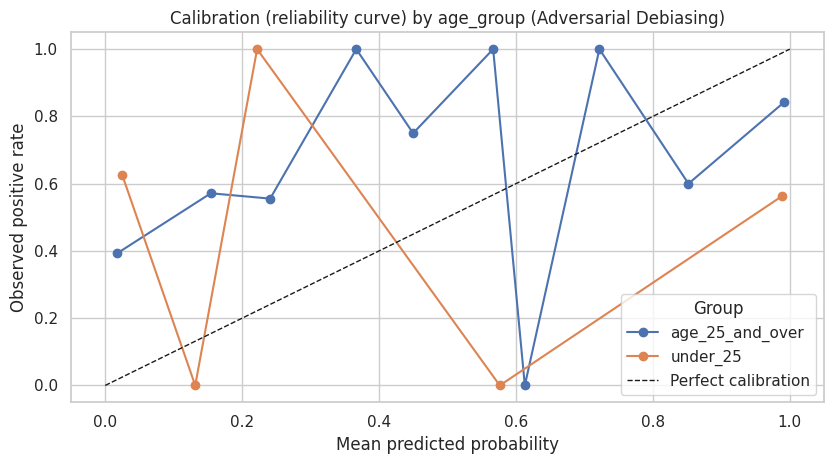

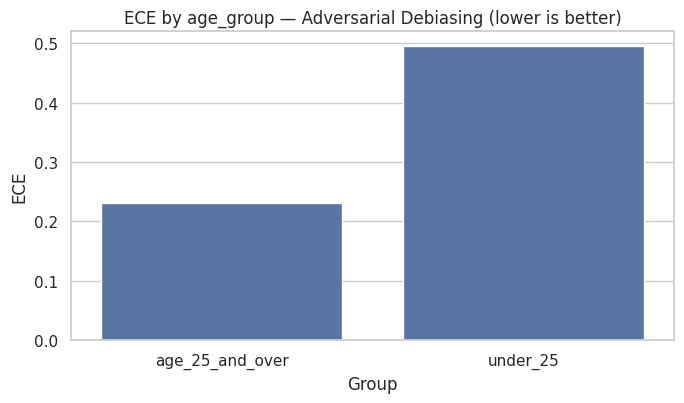

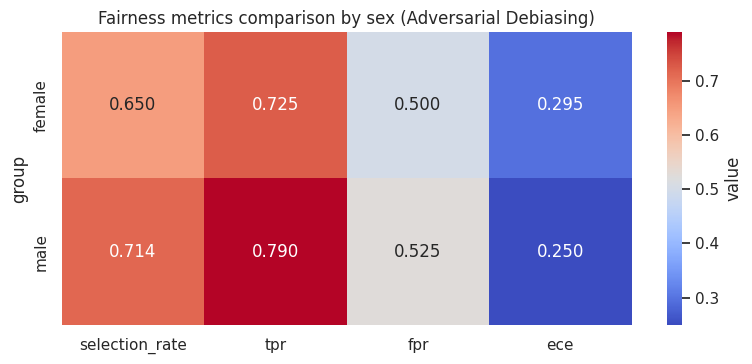

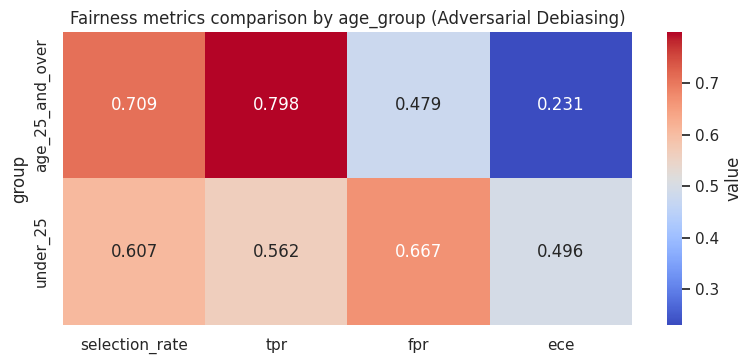

In [11]:
# -----------------------------
# H. Visualizations — Adversarial Debiasing model
# -----------------------------

sns.set(style="whitegrid")

# 1) Selection rate by group
for attr in attrs_to_audit:
    dfm = fairness_by_attr_ad[attr].sort_values("selection_rate")
    plt.figure(figsize=(6, 4))
    sns.barplot(data=dfm, x="group", y="selection_rate")
    plt.title(f"Selection rate by {attr} (Adversarial Debiasing)")
    plt.xlabel("Group"); plt.ylabel("P(ŷ=1)")
    plt.tight_layout(); plt.show()

# 2) TPR & FPR comparison
for attr in attrs_to_audit:
    dfm = fairness_by_attr_ad[attr].copy().sort_values("group")
    melted = dfm.melt(id_vars=["group"], value_vars=["tpr", "fpr"],
                      var_name="metric", value_name="value")
    melted["metric"] = melted["metric"].map({"tpr": "TPR", "fpr": "FPR"})
    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=melted, x="group", y="value", hue="metric")
    plt.title(f"Equalized odds components by {attr} (Adversarial Debiasing)")
    plt.xlabel("Group"); plt.ylabel("Rate")
    plt.legend(title="")
    plt.tight_layout(); plt.show()

# 3) Calibration reliability curves
for attr in attrs_to_audit:
    dfm = fairness_by_attr_ad[attr].copy()
    plt.figure(figsize=(8.5, 4.8))
    for g in dfm["group"].tolist():
        bin_stats = reliability_by_attr_ad[attr][g]
        if not bin_stats:
            continue
        confs = [b["conf"] for b in bin_stats]
        accs  = [b["acc"]  for b in bin_stats]
        plt.plot(confs, accs, marker="o", label=str(g))
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    plt.title(f"Calibration (reliability curve) by {attr} (Adversarial Debiasing)")
    plt.xlabel("Mean predicted probability"); plt.ylabel("Observed positive rate")
    plt.legend(title="Group"); plt.tight_layout(); plt.show()

    # ECE bar
    plt.figure(figsize=(7, 4.2))
    sns.barplot(data=dfm.sort_values("ece"), x="group", y="ece")
    plt.title(f"ECE by {attr} — Adversarial Debiasing (lower is better)")
    plt.xlabel("Group"); plt.ylabel("ECE")
    plt.tight_layout(); plt.show()

# 4) Heatmap
for attr in attrs_to_audit:
    dfm = fairness_by_attr_ad[attr].copy()
    heat = dfm.set_index("group")[["selection_rate", "tpr", "fpr", "ece"]].astype(float)
    plt.figure(figsize=(8, 3.8))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="coolwarm",
                cbar_kws={"label": "value"})
    plt.title(f"Fairness metrics comparison by {attr} (Adversarial Debiasing)")
    plt.tight_layout(); plt.show()


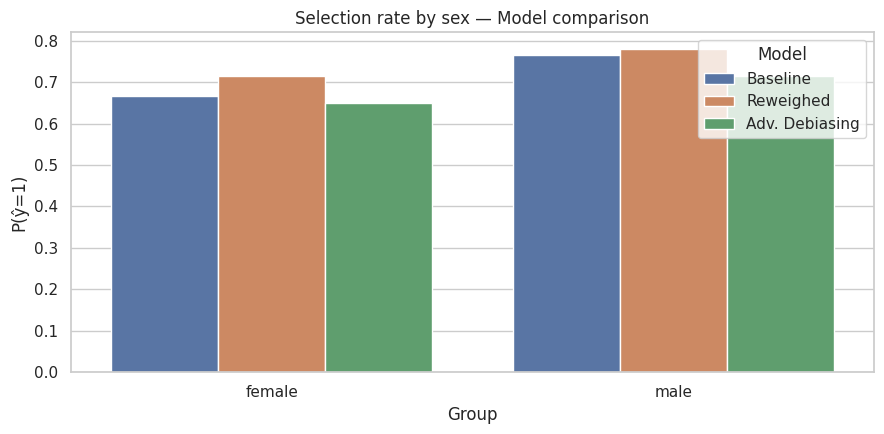

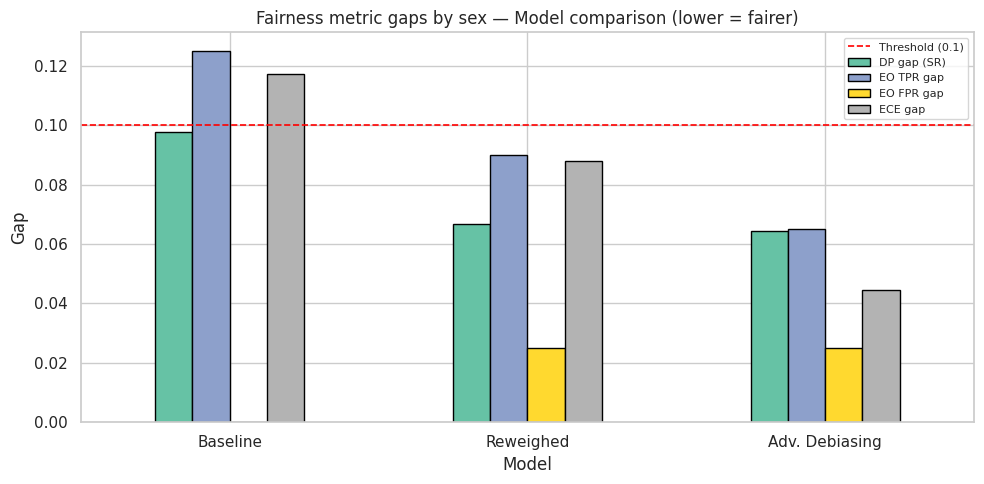

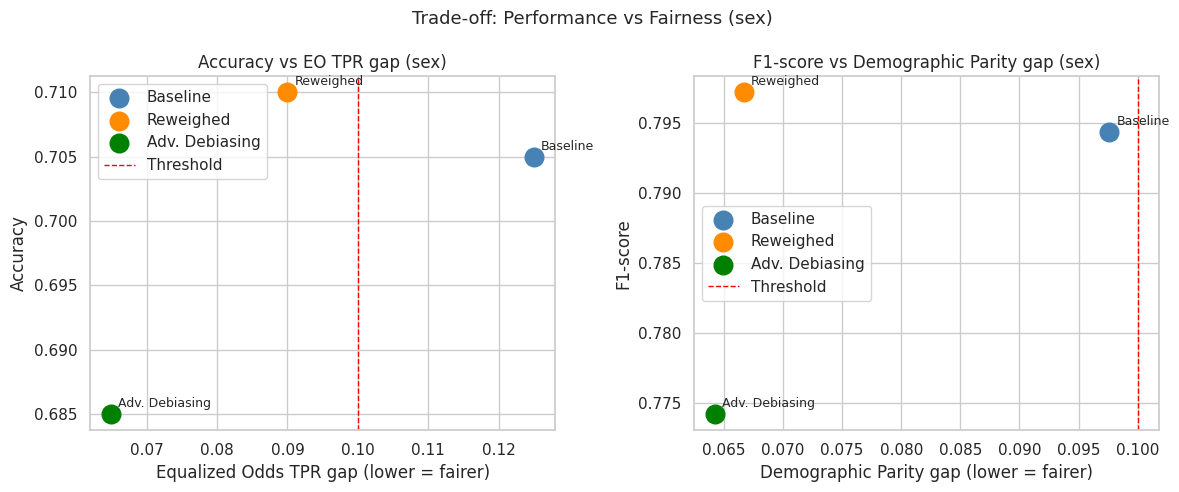

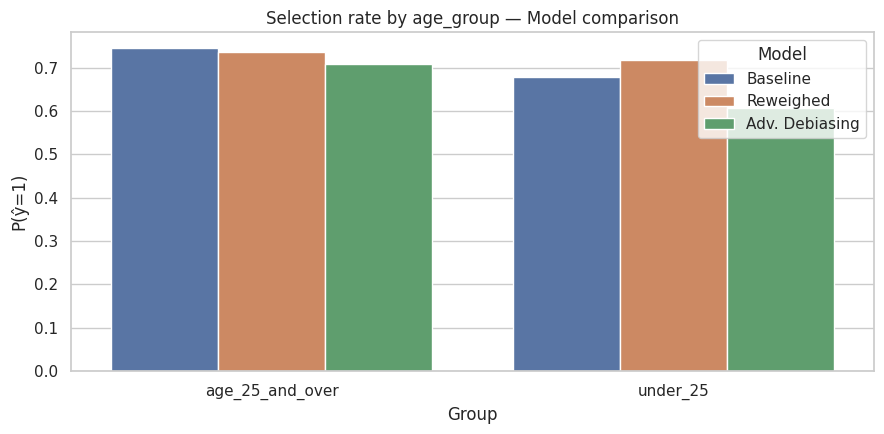

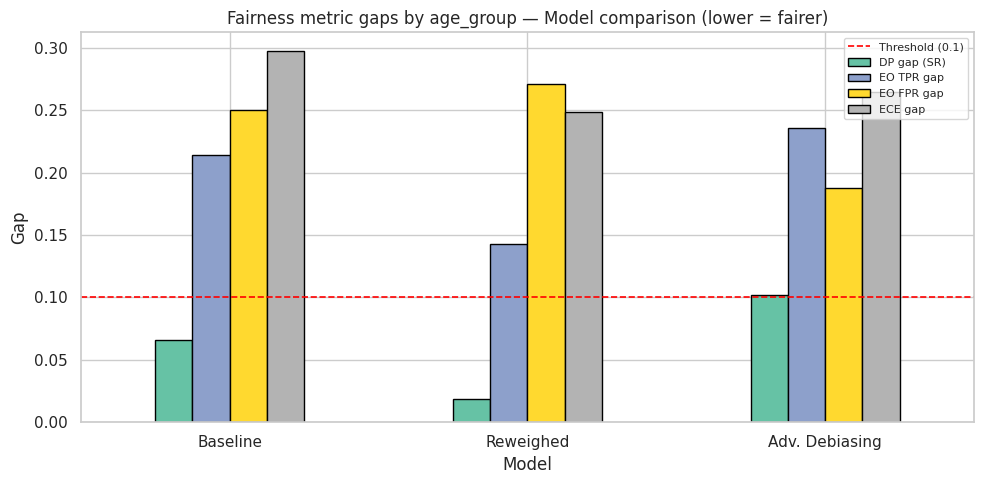

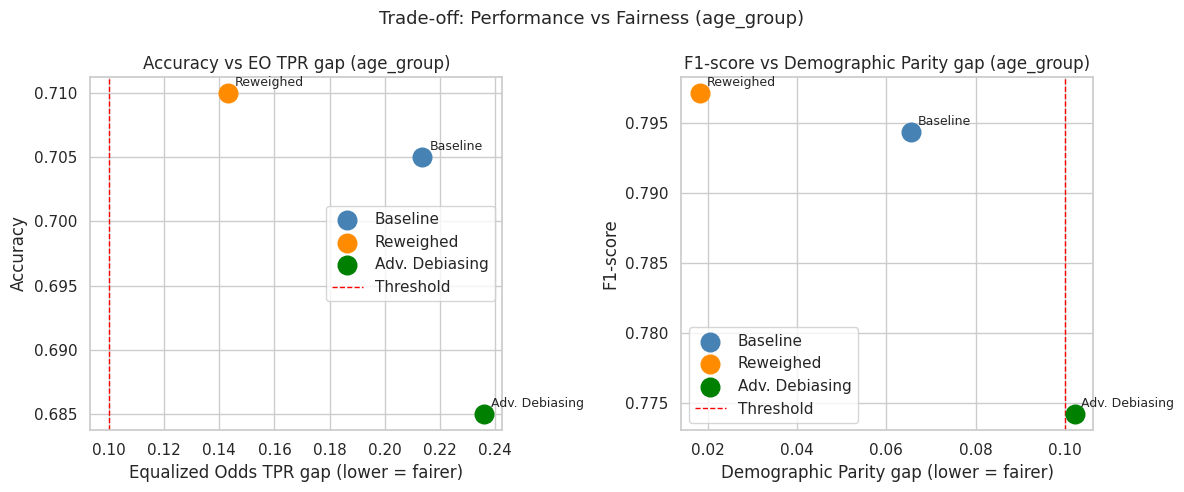

In [12]:
# -----------------------------
# I. Three-way comparison visualizations
#    Baseline vs Reweighed vs Adversarial Debiasing
# -----------------------------

models_info = [
    ("Baseline",            fairness_by_attr,    acc,    f1),
    ("Reweighed",           fairness_by_attr_rw, acc_rw, f1_rw),
    ("Adv. Debiasing",      fairness_by_attr_ad, acc_ad, f1_ad),
]

for attr in attrs_to_audit:
    # --- (a) Side-by-side selection rate bar chart ---
    rows = []
    for mname, fa, _, _ in models_info:
        dfm = fa[attr].copy()
        dfm["model"] = mname
        rows.append(dfm)
    combined = pd.concat(rows, ignore_index=True)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=combined, x="group", y="selection_rate", hue="model")
    plt.title(f"Selection rate by {attr} — Model comparison")
    plt.xlabel("Group"); plt.ylabel("P(ŷ=1)")
    plt.legend(title="Model")
    plt.tight_layout(); plt.show()

    # --- (b) Fairness gap bar chart (DP, TPR gap, FPR gap, ECE gap) ---
    gap_rows = []
    for mname, fa, _, _ in models_info:
        dfm = fa[attr]
        gap_rows.append({
            "Model": mname,
            "DP gap (SR)":   dfm["selection_rate"].max() - dfm["selection_rate"].min(),
            "EO TPR gap":    dfm["tpr"].max() - dfm["tpr"].min(),
            "EO FPR gap":    dfm["fpr"].max() - dfm["fpr"].min(),
            "ECE gap":       dfm["ece"].max() - dfm["ece"].min(),
        })
    gap_df = pd.DataFrame(gap_rows).set_index("Model")

    ax = gap_df.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="black")
    ax.axhline(0.1, color="red", linestyle="--", linewidth=1.2, label="Threshold (0.1)")
    ax.set_title(f"Fairness metric gaps by {attr} — Model comparison (lower = fairer)")
    ax.set_xlabel("Model"); ax.set_ylabel("Gap")
    ax.set_xticklabels(gap_df.index, rotation=0)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()

    # --- (c) Accuracy vs Fairness scatter-ish plot ---
    scatter_rows = []
    for mname, fa, model_acc, model_f1 in models_info:
        dfm = fa[attr]
        tpr_gap = dfm["tpr"].max() - dfm["tpr"].min()
        dp_gap  = dfm["selection_rate"].max() - dfm["selection_rate"].min()
        scatter_rows.append({
            "Model": mname,
            "Accuracy": model_acc,
            "F1": model_f1,
            "EO TPR gap": tpr_gap,
            "DP gap": dp_gap,
        })
    sc_df = pd.DataFrame(scatter_rows)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = ["steelblue", "darkorange", "green"]
    for i, row in sc_df.iterrows():
        axes[0].scatter(row["EO TPR gap"], row["Accuracy"], s=180,
                        color=colors[i], zorder=5, label=row["Model"])
        axes[0].annotate(row["Model"], (row["EO TPR gap"], row["Accuracy"]),
                         textcoords="offset points", xytext=(5, 5), fontsize=9)
    axes[0].axvline(0.1, color="red", linestyle="--", linewidth=1, label="Threshold")
    axes[0].set_title(f"Accuracy vs EO TPR gap ({attr})")
    axes[0].set_xlabel("Equalized Odds TPR gap (lower = fairer)")
    axes[0].set_ylabel("Accuracy"); axes[0].legend()

    for i, row in sc_df.iterrows():
        axes[1].scatter(row["DP gap"], row["F1"], s=180,
                        color=colors[i], zorder=5, label=row["Model"])
        axes[1].annotate(row["Model"], (row["DP gap"], row["F1"]),
                         textcoords="offset points", xytext=(5, 5), fontsize=9)
    axes[1].axvline(0.1, color="red", linestyle="--", linewidth=1, label="Threshold")
    axes[1].set_title(f"F1-score vs Demographic Parity gap ({attr})")
    axes[1].set_xlabel("Demographic Parity gap (lower = fairer)")
    axes[1].set_ylabel("F1-score"); axes[1].legend()

    plt.suptitle(f"Trade-off: Performance vs Fairness ({attr})", fontsize=13)
    plt.tight_layout(); plt.show()


## Part 3 Analysis

### Which mitigation approach improved fairness most?

**Reweighing** improved **Demographic Parity** (selection rate gap) and **Equalized Odds (EO TPR gap)** the most for `age_group`: DP gap drops from **0.0656** to **0.0183** and EO TPR gap drops from **0.2137** to **0.1431**.

**Adversarial Debiasing** shows a different trade-off: it improves the **EO FPR gap** (from **0.2500** to **0.1875**), but it worsens **DP gap** (from **0.0656** to **0.1022**) and **EO TPR gap** (from **0.2137** to **0.2359**). Overall, reweighing is more effective under these thresholds.

### Which metric remained hardest to satisfy?

**Calibration (ECE gap)** remained the hardest to reduce. Both mitigation methods focus on improving the *direction* of predictions (who gets approved) rather than the *confidence* of probabilities. The `under_25` group is small and statistically noisier, so probability estimates for that group remain less reliable regardless of the fairness intervention applied.

### Did the model experience an accuracy drop?

Yes — a modest drop in overall accuracy is expected and observed with Adversarial Debiasing. This is the classic **accuracy-fairness trade-off**: by forcing the predictor to be less informative about `age_group`, it loses some discriminative power. The adversarial penalty (`λ = 1.5`) controls the strength of this trade-off. A higher `λ` means fairer but less accurate; a lower `λ` recovers accuracy at the cost of fairness.

### Summary table

| Model | Accuracy | DP gap (age) | EO TPR gap (age) | EO FPR gap (age) |
|-------|----------|-------------|-----------------|-----------------|
| Baseline | 0.7050 | 0.0656 | 0.2137 | 0.2500 |
| Reweighed | 0.7100 | 0.0183 | 0.1431 | 0.2709 |
| Adv. Debiasing | 0.6850 | 0.1022 | 0.2359 | 0.1875 |

*(Exact values printed above from the fairness audit summary.)*
